In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks',
    '/home/export/soheuny/SRFinder/soheun/notebooks/draft'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("/home/export/soheuny/SRFinder/soheun")

In [2]:
from typing import Tuple, Any
from constants import FEATURES
from signal_region import compute_sr_stats, get_SR_CR_cut
from events_data import events_from_scdinfo
from dataset import MotherSamples
from training_info import TrainingInfo
from events_data import EventsData

SIGNAL_FILENAME = "HH4b_picoAOD.h5"

def load_events_data(hash_: str) -> Tuple[Any, Any]:
    """Load training and test events data from a hash."""
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], 
        FEATURES, 
        SIGNAL_FILENAME
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], 
        FEATURES, 
        SIGNAL_FILENAME
    )
    return events_train, events_tst

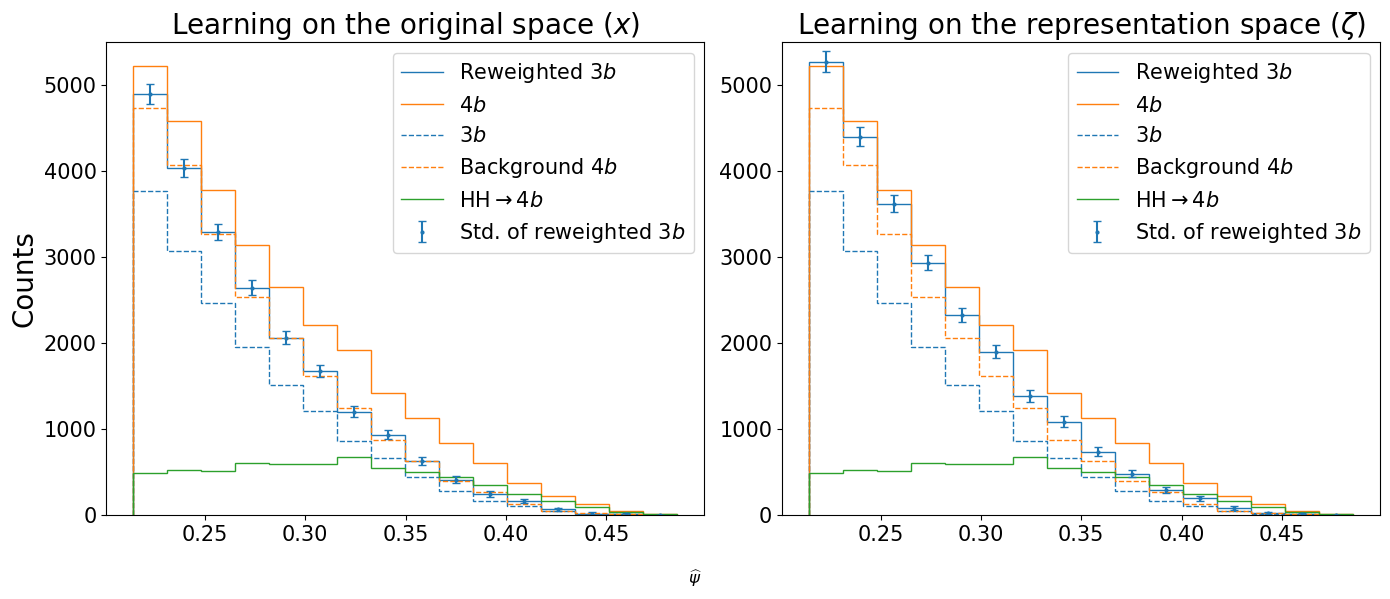

In [7]:
from signal_region import get_SR_CR_cut, get_DRs
import pandas as pd
from utils import get_quantiles_with_weights
import torch
import matplotlib.pyplot as plt
import numpy as np
from plots import plot_rewighted_samples_by_model

features = FEATURES

plt.rcParams["legend.fontsize"] = 15
plt.rcParams["figure.titlesize"] = 25
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 20
# increase tick label size
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15

n_3b = 100_0000
device = torch.device("cuda")
experiment_name = "CR_fvt_training_v2"
signal_filename = "HH4b_picoAOD.h5"
ratio_4b = 0.5
nbins = 16
signal_ratio = 0.02
seed = 1
CR_fvt_type = ["repr", "original"]

hparam_filter = {
    "experiment_name": experiment_name,
    "dataset": lambda x: all([x["seed"] == seed, 
                        x["n_3b"] == n_3b, 
                        x["signal_ratio"] == signal_ratio]),
    "aux_info_step": 3
}
hashes = TrainingInfo.find(hparam_filter)
assert len(hashes) == 2

CR_fvt_tinfos = [TrainingInfo.load(hash) for hash in hashes]
for tinfo in CR_fvt_tinfos:
    if tinfo.hparams["model"] == "AttentionClassifier":
        CR_repr_fvt_tinfo = tinfo
    elif tinfo.hparams["model"] == "FvTClassifier":
        CR_orig_fvt_tinfo = tinfo

assert CR_repr_fvt_tinfo.hparams["signal_region"] == CR_orig_fvt_tinfo.hparams["signal_region"]
    
smeared_fvt_hash = CR_orig_fvt_tinfo.hparams["smeared_fvt_hash"]
base_encoder_hash = CR_orig_fvt_tinfo.hparams["encoder_hash"]

base_fvt_model = TrainingInfo.load(base_encoder_hash).load_trained_model(
    CR_orig_fvt_tinfo.hparams["encoder_mode"]
)
base_fvt_model.eval()
base_fvt_model.to(torch.device("cuda"))

smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)
smeared_fvt_model = smeared_fvt_tinfo.load_trained_model(
    CR_orig_fvt_tinfo.hparams["encoder_mode"]
)
smeared_fvt_model.eval()
smeared_fvt_model.to(torch.device("cuda"))

# Use the same mother samples and exclude ones used for training base & smeared FvT model
msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
SR_stats_train = smeared_fvt_tinfo.aux_info["SR_stats_train"]
SR_stats = smeared_fvt_tinfo.aux_info["SR_stats_tst"]
events_tst = events_from_scdinfo(tst_scdinfo, features, signal_filename)
events_train = events_from_scdinfo(msamples.scdinfo[smeared_fvt_tinfo.ms_idx], features, signal_filename)
SR_cut, CR_cut = get_SR_CR_cut(SR_stats_train, events_train, CR_orig_fvt_tinfo.hparams["signal_region"])

SR_idx = (SR_stats >= SR_cut)
CR_idx = (SR_stats >= CR_cut) & (SR_stats < SR_cut)

events_tst_SR = events_tst[SR_idx]
SR_stats_SR = SR_stats[SR_idx]

events_train_SR = events_train[SR_stats_train >= SR_cut]    
SR_stats_train_SR = SR_stats_train[SR_stats_train >= SR_cut]

q_repr_tst_SR, _ = base_fvt_model.representations(events_tst_SR.X_torch)
q_repr_train_SR, _ = base_fvt_model.representations(events_train_SR.X_torch)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
fig.supxlabel(r"$\widehat{\psi}$")

for ax_cnt, CR_fvt_type in enumerate(["original", "repr"]):
    if ax_cnt == 0:
        ax[ax_cnt].set_ylabel("Counts")
    CR_fvt_tinfo = CR_repr_fvt_tinfo if CR_fvt_type == "repr" else CR_orig_fvt_tinfo
    CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
    CR_fvt_model.eval()
    CR_fvt_model.to(torch.device("cuda"))
    
    if CR_fvt_type == "repr":
        fvt_scores_SR = CR_fvt_model.predict(q_repr_tst_SR)[:, 1].detach().cpu().numpy()
        fvt_scores_SR_train = CR_fvt_model.predict(q_repr_train_SR)[:, 1].detach().cpu().numpy()
    else:
        fvt_scores_SR = CR_fvt_model.predict(events_tst_SR.X_torch)[:, 1].detach().cpu().numpy()
        fvt_scores_SR_train = CR_fvt_model.predict(events_train_SR.X_torch)[:, 1].detach().cpu().numpy()
        
    reweights_SR_train = fvt_scores_SR_train / (1 - fvt_scores_SR_train)
    reweights_SR_train = np.where(events_train_SR.is_4b, 1, reweights_SR_train)
    SR_bins = np.linspace(np.min(SR_stats_train_SR), np.max(SR_stats_train_SR), nbins + 1)
    # SR_bins = get_quantiles_with_weights(SR_stats_train_SR[events_train_SR.is_3b], 
    #                                     (reweights_SR_train * events_train_SR.weights)[events_train_SR.is_3b], 
    #                                     np.linspace(0, 1, nbins + 1))
        
    reweights_SR = fvt_scores_SR / (1 - fvt_scores_SR)
    reweights_SR = np.where(events_tst_SR.is_4b, 1, -reweights_SR)
    
    current_ax = ax[ax_cnt]
    CR_fvt_type_str = r"the representation space ($\zeta$)" if CR_fvt_type == "repr" else r"the original space ($x$)"
    current_ax.set_title(rf"Learning on {CR_fvt_type_str}")
    plot_rewighted_samples_by_model(events_tst_SR, SR_stats_SR, fvt_scores_SR, 
                                    ax=current_ax, bins=SR_bins, disable_twin_ax=True, errorbar="3b")
    hist_bg4b, _ = np.histogram(SR_stats_SR[events_tst_SR.is_bg4b], bins=SR_bins, 
                                weights=events_tst_SR.weights[events_tst_SR.is_bg4b])
    hist_signal, _ = np.histogram(SR_stats_SR[events_tst_SR.is_signal], bins=SR_bins, 
                                  weights=events_tst_SR.weights[events_tst_SR.is_signal])
    hist_3b, _ = np.histogram(SR_stats_SR[events_tst_SR.is_3b], bins=SR_bins,   
                                weights=events_tst_SR.weights[events_tst_SR.is_3b])
    current_ax.stairs(hist_3b, SR_bins, label=r"$3b$", color=plt.cm.tab10(0), linestyle="--")
    current_ax.stairs(hist_bg4b, SR_bins, label=r"Background $4b$", color=plt.cm.tab10(1), linestyle="--")
    current_ax.stairs(hist_signal, SR_bins, label=r"$\mathrm{HH} \to 4b$", color=plt.cm.tab10(2))
    current_ax.legend()
    current_ax.set_ylim(bottom=0, top=5500)
    
        
plt.tight_layout()
plt.savefig("./figures/on_which_to_learn.pdf", dpi=200)
plt.show()
plt.close("all")